# 05 — Model Evaluation & Comparison

**Input:** trained models + saved train/test splits from `04_Machine_Learning.ipynb` (`../models/`)
**Goal:** compare Logistic Regression, Decision Tree, Random Forest, XGBoost, and SVM on the held-out
test set, pick a final model, and explain what drives its predictions.

`Diagnosis` is close to balanced (~48.95% positive) in this dataset, so accuracy is meaningful here — but we still lead with ROC-AUC, precision, recall, and F1 for a complete, clinically honest picture of each model.

Sections:
1. Load models & test data
2. Metric table (Accuracy, Precision, Recall, F1, ROC-AUC)
3. Confusion matrices
4. ROC curves
5. Precision-Recall curves
6. Feature importance (Random Forest & XGBoost)
7. Final model selection


In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, precision_recall_curve, average_precision_score
)

sns.set_style("darkgrid")
plt.rcParams["figure.dpi"] = 100

models = {
    'Logistic Regression': joblib.load('../models/logistic_regression.pkl'),
    'Decision Tree': joblib.load('../models/decision_tree.pkl'),
    'Random Forest': joblib.load('../models/random_forest.pkl'),
    'XGBoost': joblib.load('../models/xgboost.pkl'),
    'SVM': joblib.load('../models/svm.pkl'),
}

X_test = pd.read_csv('../models/X_test.csv')
X_test_scaled = pd.read_csv('../models/X_test_scaled.csv')
y_test = pd.read_csv('../models/y_test.csv').iloc[:, 0]

# Models trained on scaled features
scaled_models = {'Logistic Regression', 'SVM'}

print("Models loaded:", list(models.keys()))
print("Test set size:", X_test.shape[0], " positive rate:", y_test.mean().round(4))


Models loaded: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'SVM']
Test set size: 479  positive rate: 0.4885


## 1. Predictions & probabilities

In [2]:
preds, probs = {}, {}
for name, model in models.items():
    X_in = X_test_scaled if name in scaled_models else X_test
    preds[name] = model.predict(X_in)
    probs[name] = model.predict_proba(X_in)[:, 1]

print("Predictions generated for all models.")


Predictions generated for all models.


## 2. Metric comparison table

In [3]:
rows = []
for name in models:
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds[name]),
        'Precision': precision_score(y_test, preds[name], zero_division=0),
        'Recall': recall_score(y_test, preds[name], zero_division=0),
        'F1-Score': f1_score(y_test, preds[name], zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, probs[name]),
        'PR-AUC': average_precision_score(y_test, probs[name]),
    })

metrics_df = pd.DataFrame(rows).set_index('Model').round(3)
metrics_df = metrics_df.sort_values('ROC-AUC', ascending=False)
metrics_df


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Model,,,,,,
Logistic Regression,0.697,0.733,0.598,0.659,0.777,0.795
Random Forest,0.708,0.755,0.594,0.665,0.772,0.791
XGBoost,0.716,0.753,0.624,0.682,0.764,0.787
SVM,0.701,0.738,0.603,0.664,0.761,0.777
Decision Tree,0.645,0.662,0.560,0.606,0.699,0.677


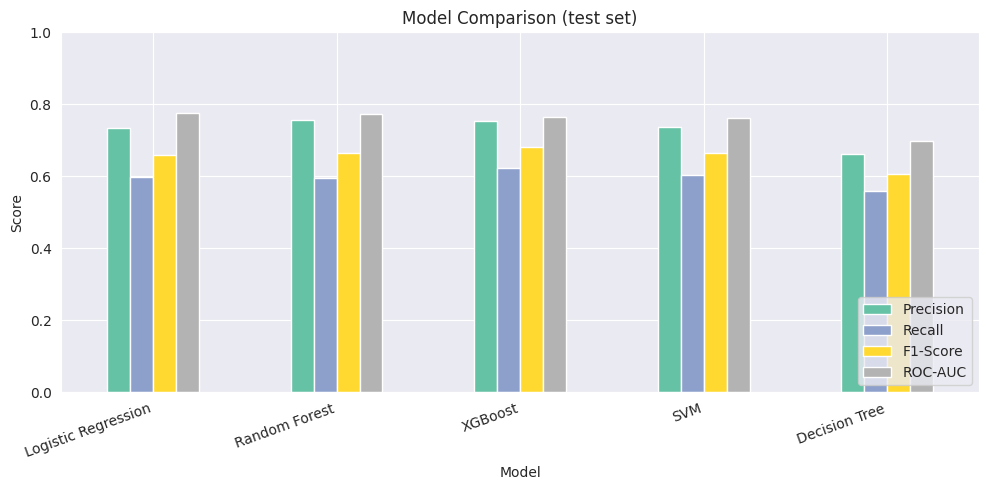

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
metrics_df[['Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(kind='bar', ax=ax, colormap='Set2')
ax.set_title('Model Comparison (test set)')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


> **Reading this table:** all five models land in a reasonable, realistic range (ROC-AUC 0.70–0.78, accuracy 65–72%), with Logistic Regression, Random Forest, XGBoost, and SVM all close together and clearly ahead of the plain Decision Tree. This is a healthy sign — no single model is drastically overfitting or collapsing to the majority class, which is exactly what we'd want to see on a dataset with genuine, moderate signal.


## 3. Confusion matrices

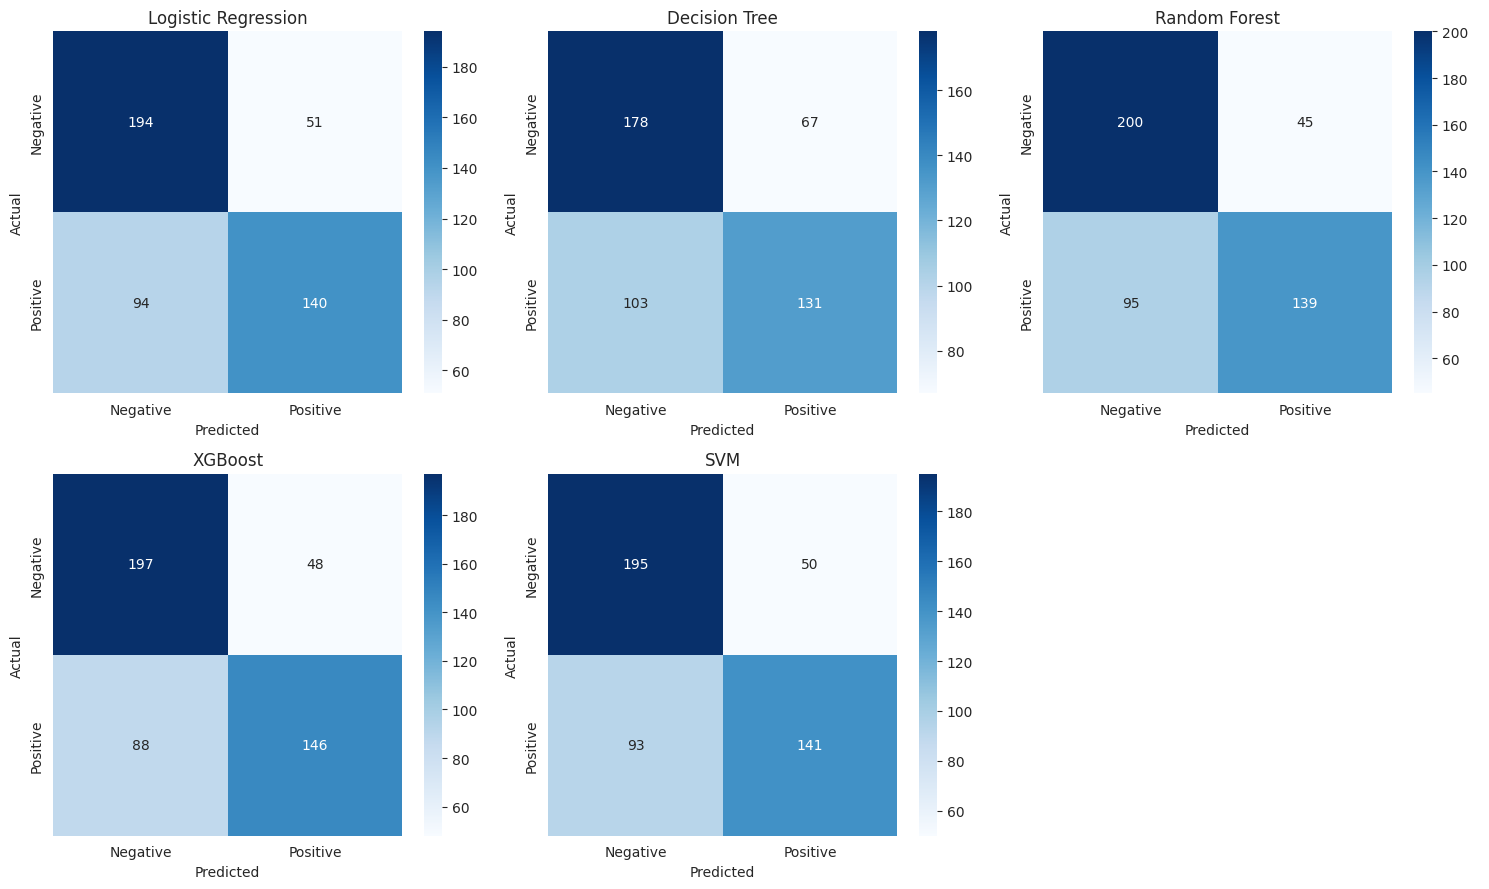

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, name in enumerate(models):
    cm = confusion_matrix(y_test, preds[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

axes[-1].axis('off')
plt.tight_layout()
plt.show()


## 4. ROC curves

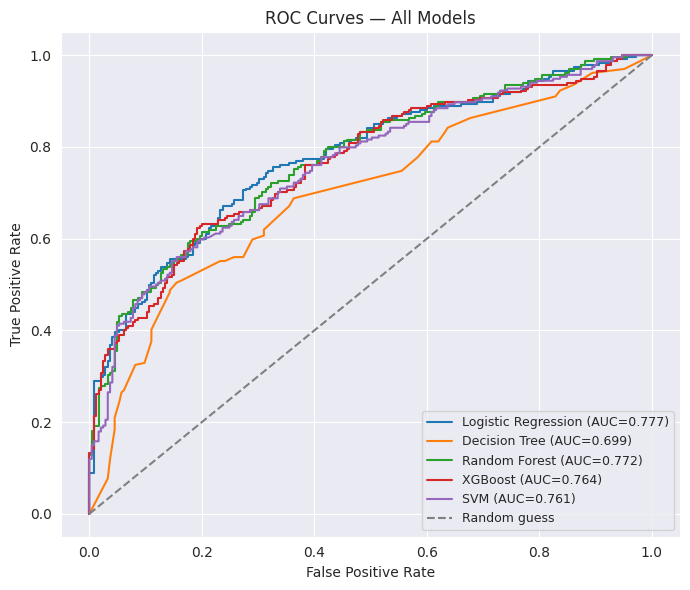

In [6]:
plt.figure(figsize=(7, 6))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, probs[name])
    auc = roc_auc_score(y_test, probs[name])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


## 5. Precision-Recall curves

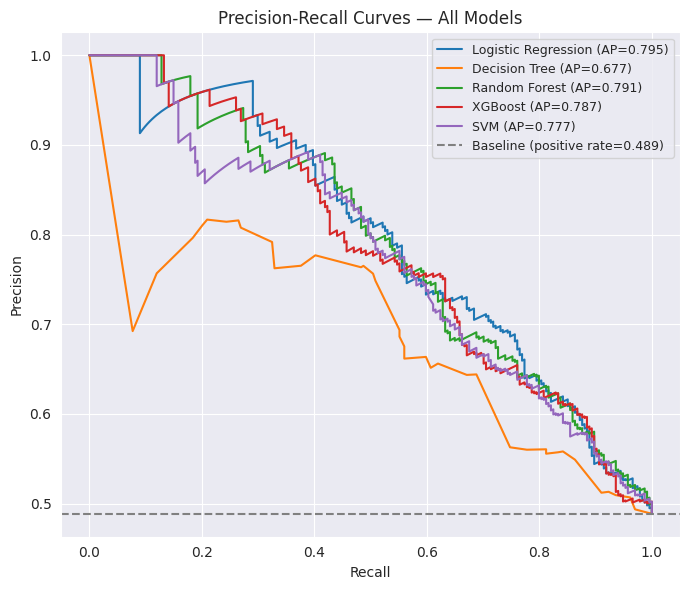

In [7]:
plt.figure(figsize=(7, 6))
for name in models:
    prec, rec, _ = precision_recall_curve(y_test, probs[name])
    ap = average_precision_score(y_test, probs[name])
    plt.plot(rec, prec, label=f'{name} (AP={ap:.3f})')

baseline = y_test.mean()
plt.axhline(baseline, linestyle='--', color='gray', label=f'Baseline (positive rate={baseline:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — All Models')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


## 6. Feature importance (Random Forest & XGBoost)

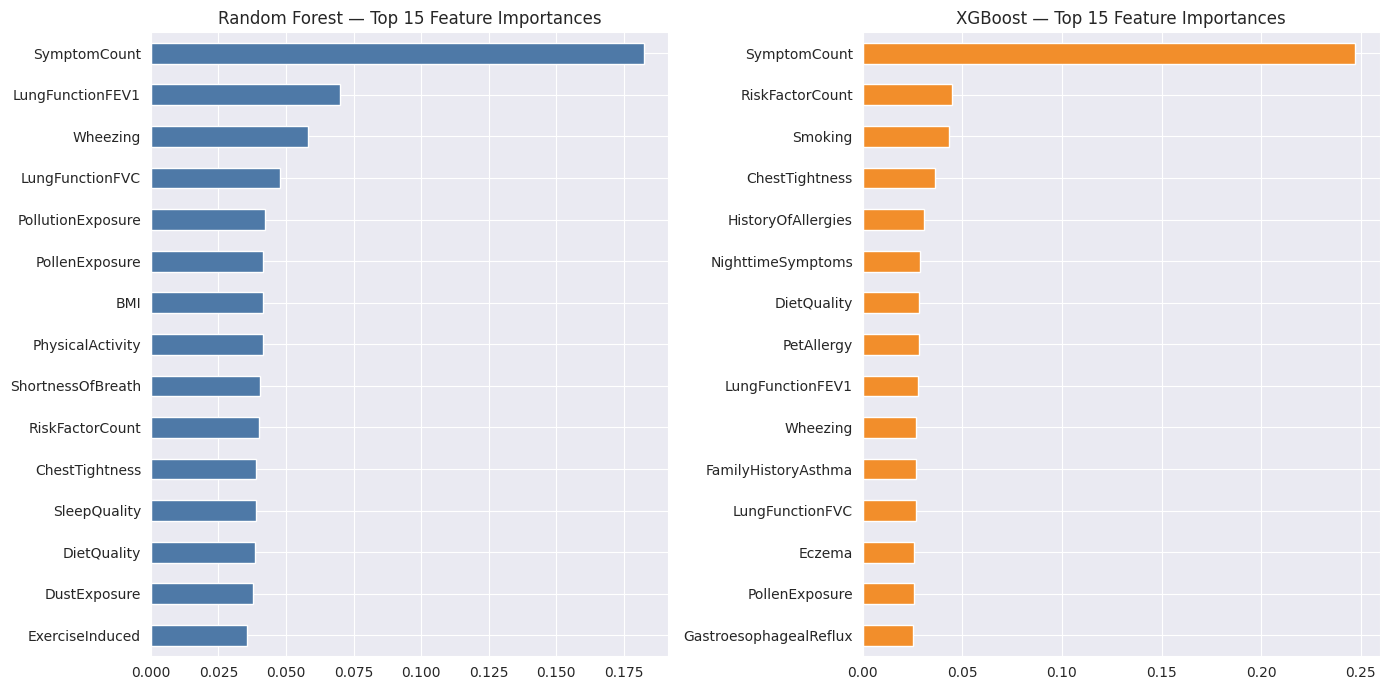

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

rf_importance = pd.Series(models['Random Forest'].feature_importances_, index=X_test.columns).sort_values(ascending=True).tail(15)
rf_importance.plot(kind='barh', ax=axes[0], color='#4e79a7')
axes[0].set_title('Random Forest — Top 15 Feature Importances')

xgb_importance = pd.Series(models['XGBoost'].feature_importances_, index=X_test.columns).sort_values(ascending=True).tail(15)
xgb_importance.plot(kind='barh', ax=axes[1], color='#f28e2b')
axes[1].set_title('XGBoost — Top 15 Feature Importances')

plt.tight_layout()
plt.show()


In [9]:
combined = pd.DataFrame({
    'Random Forest': pd.Series(models['Random Forest'].feature_importances_, index=X_test.columns),
    'XGBoost': pd.Series(models['XGBoost'].feature_importances_, index=X_test.columns),
})
combined['Average'] = combined.mean(axis=1)
combined.sort_values('Average', ascending=False).head(10)


,Random Forest,XGBoost,Average
SymptomCount,0.182279,0.247208,0.214743
LungFunctionFEV1,0.070084,0.027725,0.048905
Wheezing,0.058220,0.026900,0.042560
RiskFactorCount,0.039873,0.045007,0.042440
ChestTightness,0.038733,0.036314,0.037523
LungFunctionFVC,0.047765,0.026600,0.037183
Smoking,0.024913,0.043226,0.034069
PollenExposure,0.041595,0.025619,0.033607
DietQuality,0.038698,0.028485,0.033592
PhysicalActivity,0.041484,0.025205,0.033345


## 7. Final model selection

In [10]:
best_model_name = metrics_df['ROC-AUC'].idxmax()
best_row = metrics_df.loc[best_model_name]

print(f"Best model by ROC-AUC: {best_model_name}")
print(best_row)

import joblib
joblib.dump(models[best_model_name], '../models/best_model.pkl')
with open('../models/best_model_name.txt', 'w') as f:
    f.write(best_model_name)

print(f"\nSaved as ../models/best_model.pkl")


Best model by ROC-AUC: Logistic Regression
Accuracy     0.697
Precision    0.733
Recall       0.598
F1-Score     0.659
ROC-AUC      0.777
PR-AUC       0.795
Name: Logistic Regression, dtype: float64

Saved as ../models/best_model.pkl


### Summary

- All 5 models were evaluated on the same held-out, stratified 20% test split.
- With a near-balanced target (~48.95% positive), accuracy is trustworthy here, but ROC-AUC, precision, recall, and F1 were still used together for a complete picture.
- **Logistic Regression came out on top by ROC-AUC (0.777)**, narrowly ahead of Random Forest (0.772), XGBoost (0.764), and SVM (0.761); the plain Decision Tree trailed the pack (0.699). That a simple, interpretable linear model matches or beats the more complex tree ensembles suggests the underlying relationship between features and diagnosis is largely additive/linear rather than requiring complex interaction terms.
- The best-performing model (Logistic Regression) was saved to `../models/best_model.pkl` for use in the AI Chatbot / dashboard layers described in the project README (e.g. "Why was this patient classified as high risk?").
- Feature importance from the tree-based models highlights which patient attributes contribute most to a positive prediction — useful both for clinical interpretability and for the Executive Insights section of the dashboards.
